In [1]:
!pip install albumentations onnx onnxruntime -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 97.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 102.1 MB/s eta 0:00:00


In [2]:
import os
import copy
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score
)
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Vérifier le GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device utilisé : {device}")
if device.type == "cuda":
    print(f"GPU : {torch.cuda.get_device_name(0)}")

EMOTIONS = ["angry", "disgusted", "fearful", "happy", "neutral", "sad", "surprised"]
NUM_CLASSES = len(EMOTIONS)
IMG_SIZE = 48
BATCH_SIZE = 64
EPOCHS = 60
LR = 1e-3
DATA_DIR = "./data"

Device utilisé : cuda
GPU : Tesla T4


In [3]:
from google.colab import files
uploaded = files.upload()   # uploader le ZIP
import zipfile
with zipfile.ZipFile('archive.zip') as z: z.extractall('data/')

Saving archive.zip to archive.zip


EXPLORATION DU DATASET FER

--- TRAIN ---
  angry       :  3995 images
  disgusted   :   436 images
  fearful     :  4097 images
  happy       :  7215 images
  neutral     :  4965 images
  sad         :  4830 images
  surprised   :  3171 images
  TOTAL       : 28709 images

--- TEST ---
  angry       :   958 images
  disgusted   :   111 images
  fearful     :  1024 images
  happy       :  1774 images
  neutral     :  1233 images
  sad         :  1247 images
  surprised   :   831 images
  TOTAL       :  7178 images


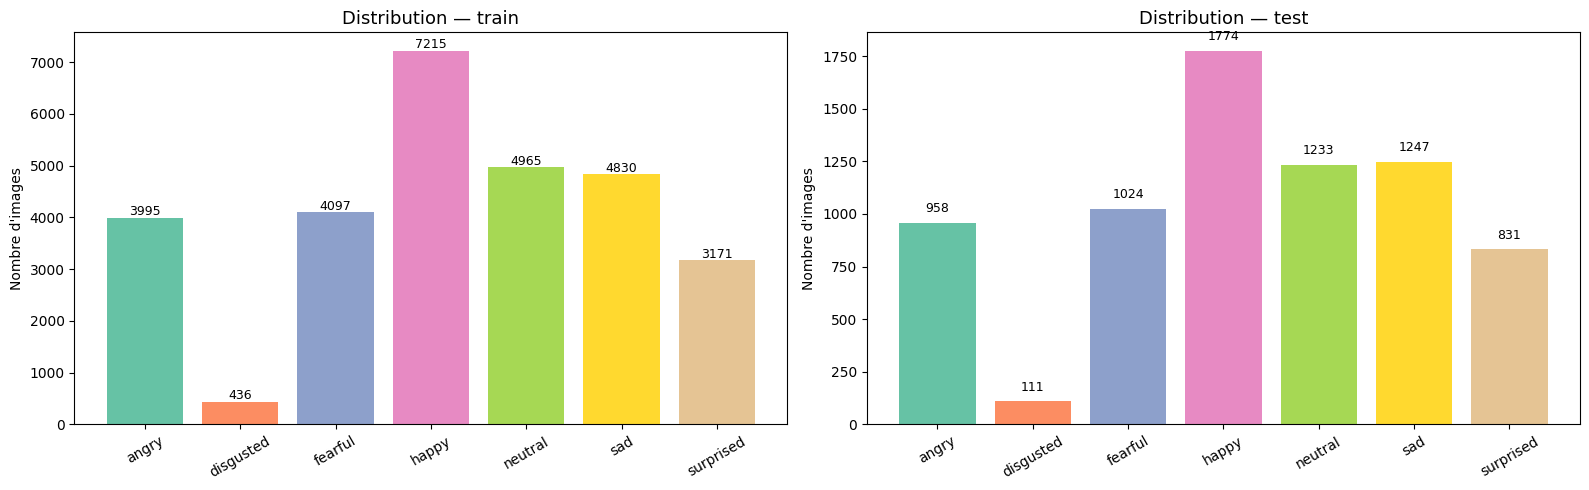


Graphique sauvegardé : dataset_distribution.png


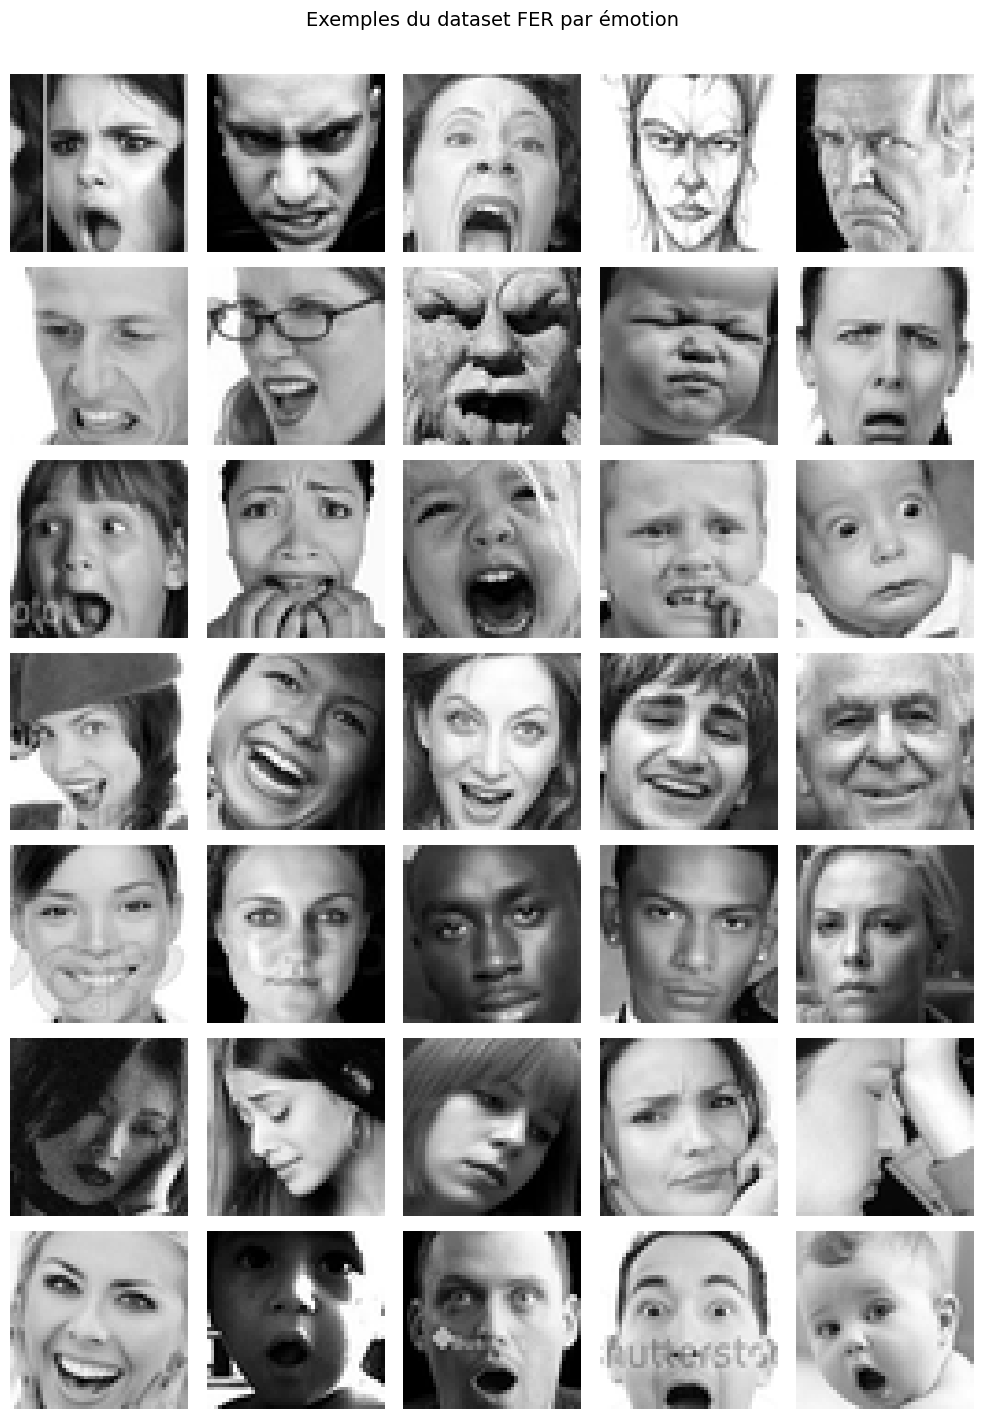

In [4]:
def explore_dataset(data_dir):
    print("=" * 50)
    print("EXPLORATION DU DATASET FER")
    print("=" * 50)

    for split in ["train", "test"]:
        split_dir = os.path.join(data_dir, split)
        if not os.path.exists(split_dir):
            print(f"Dossier {split_dir} introuvable.")
            continue

        print(f"\n--- {split.upper()} ---")
        counts = {}
        for emotion in EMOTIONS:
            path = os.path.join(split_dir, emotion)
            if os.path.exists(path):
                n = len([f for f in os.listdir(path)
                         if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
                counts[emotion] = n
                print(f"  {emotion:12s}: {n:5d} images")
        print(f"  {'TOTAL':12s}: {sum(counts.values()):5d} images")

    # Visualisation distribution
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    for idx, split in enumerate(["train", "test"]):
        split_dir = os.path.join(data_dir, split)
        counts = {}
        for e in EMOTIONS:
            p = os.path.join(split_dir, e)
            if os.path.exists(p):
                counts[e] = len(os.listdir(p))
        ax = axes[idx]
        bars = ax.bar(counts.keys(), counts.values(),
                      color=plt.cm.Set2(range(len(counts))))
        ax.set_title(f"Distribution — {split}", fontsize=13)
        ax.set_ylabel("Nombre d'images")
        ax.tick_params(axis='x', rotation=30)
        for bar, val in zip(bars, counts.values()):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 50,
                    str(val), ha='center', fontsize=9)
    plt.tight_layout()
    plt.savefig("dataset_distribution.png", dpi=150)
    plt.show()
    print("\nGraphique sauvegardé : dataset_distribution.png")


def show_sample_images(data_dir, n_per_class=5):
    fig, axes = plt.subplots(NUM_CLASSES, n_per_class,
                             figsize=(n_per_class * 2, NUM_CLASSES * 2))
    fig.suptitle("Exemples du dataset FER par émotion",
                 fontsize=14, y=1.01)
    for i, emotion in enumerate(EMOTIONS):
        folder = os.path.join(data_dir, "train", emotion)
        if not os.path.exists(folder):
            continue
        images = os.listdir(folder)[:n_per_class]
        for j, img_name in enumerate(images):
            img = Image.open(os.path.join(folder, img_name)).convert("L")
            axes[i][j].imshow(img, cmap="gray")
            axes[i][j].axis("off")
            if j == 0:
                axes[i][j].set_ylabel(emotion, fontsize=10,
                                       labelpad=40, rotation=0)
    plt.tight_layout()
    plt.savefig("sample_images.png", dpi=150, bbox_inches="tight")
    plt.show()


explore_dataset(DATA_DIR)
show_sample_images(DATA_DIR)

In [5]:
def get_transforms():
    train_tf = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),
        transforms.RandomAffine(
            degrees=0,
            translate=(0.1, 0.1),
            scale=(0.9, 1.1),
            shear=5
        ),
        transforms.ColorJitter(brightness=0.3, contrast=0.3),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5]),
        transforms.RandomErasing(p=0.1),
    ])
    val_tf = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5]),
    ])
    return train_tf, val_tf


def get_weighted_sampler(dataset):
    """Crée un sampler équilibré pour compenser le déséquilibre des classes."""
    class_counts = Counter([label for _, label in dataset.samples])
    total = sum(class_counts.values())
    class_weights = {
        cls: total / count
        for cls, count in class_counts.items()
    }
    sample_weights = [
        class_weights[label]
        for _, label in dataset.samples
    ]
    return WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )


def build_dataloaders(data_dir, batch_size=BATCH_SIZE):
    train_tf, val_tf = get_transforms()

    train_dataset = datasets.ImageFolder(
        os.path.join(data_dir, "train"), transform=train_tf
    )
    test_dataset = datasets.ImageFolder(
        os.path.join(data_dir, "test"), transform=val_tf
    )

    sampler = get_weighted_sampler(train_dataset)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        sampler=sampler,
        num_workers=2,
        pin_memory=True,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True,
    )

    # Class weights pour la loss
    class_counts = Counter([label for _, label in train_dataset.samples])
    total = sum(class_counts.values())
    weights = torch.tensor(
        [total / class_counts[i] for i in range(NUM_CLASSES)],
        dtype=torch.float32
    ).to(device)

    print(f"Train : {len(train_dataset)} images, "
          f"{len(train_loader)} batches")
    print(f"Test  : {len(test_dataset)} images, "
          f"{len(test_loader)} batches")
    print(f"Classes : {train_dataset.classes}")
    return train_loader, test_loader, weights


train_loader, test_loader, class_weights = build_dataloaders(DATA_DIR)

Train : 28709 images, 449 batches
Test  : 7178 images, 113 batches
Classes : ['angry', 'disgusted', 'fearful', 'happy', 'neutral', 'sad', 'surprised']


In [6]:
class ResidualBlock(nn.Module):
    """Bloc résiduel léger pour améliorer la convergence."""
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3,
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3,
                               padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return F.relu(out)


class EmotionCNN(nn.Module):
    """
    CNN custom pour la détection d'émotions.
    Input  : (B, 1, 48, 48) — niveaux de gris
    Output : (B, 7)          — logits par émotion
    """
    def __init__(self, num_classes=NUM_CLASSES, dropout=0.5):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )
        self.layer1 = ResidualBlock(64, 64)
        self.layer2 = ResidualBlock(64, 128, stride=2)   # 24x24
        self.layer3 = ResidualBlock(128, 256, stride=2)  # 12x12
        self.layer4 = ResidualBlock(256, 512, stride=2)  # 6x6

        self.pool = nn.AdaptiveAvgPool2d(1)  # (B, 512, 1, 1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(512, num_classes)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.pool(x).flatten(1)
        x = self.dropout(x)
        return self.fc(x)


model = EmotionCNN().to(device)

# Résumé du modèle
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel()
                        for p in model.parameters() if p.requires_grad)
print(f"Paramètres totaux     : {total_params:,}")
print(f"Paramètres entraînable: {trainable_params:,}")

# Vérifier le forward pass
dummy = torch.randn(2, 1, IMG_SIZE, IMG_SIZE).to(device)
out = model(dummy)
print(f"Output shape          : {out.shape}  (attendu: [2, 7])")

Paramètres totaux     : 4,900,551
Paramètres entraînable: 4,900,551
Output shape          : torch.Size([2, 7])  (attendu: [2, 7])


In [7]:
class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.should_stop = False

    def step(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss = criterion(logits, labels)
        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += images.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels


def train(model, train_loader, test_loader, class_weights,
          epochs=EPOCHS, lr=LR, save_path="best_model.pth"):

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=lr, weight_decay=1e-4
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-6
    )
    early_stop = EarlyStopping(patience=12)

    history = {
        "train_loss": [], "train_acc": [],
        "val_loss": [], "val_acc": []
    }
    best_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())

    print(f"\n{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>10} "
          f"| {'Val Loss':>10} | {'Val Acc':>10} | {'LR':>10}")
    print("-" * 65)

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(
            model, train_loader, criterion, optimizer
        )
        val_loss, val_acc, _, _ = evaluate(
            model, test_loader, criterion
        )
        scheduler.step()
        elapsed = time.time() - t0
        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_acc:
            best_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(best_model_wts, save_path)
            mark = " ✓"
        else:
            mark = ""

        print(f"{epoch:>6} | {tr_loss:>10.4f} | {tr_acc*100:>9.2f}% "
              f"| {val_loss:>10.4f} | {val_acc*100:>9.2f}%"
              f" | {current_lr:.2e}{mark}  ({elapsed:.0f}s)")

        early_stop.step(val_loss)
        if early_stop.should_stop:
            print(f"\nEarly stopping à l'epoch {epoch}.")
            break

    print(f"\nMeilleure accuracy val : {best_acc*100:.2f}%")
    print(f"Modèle sauvegardé     : {save_path}")
    model.load_state_dict(best_model_wts)
    return model, history


model, history = train(model, train_loader, test_loader, class_weights)



 Epoch | Train Loss |  Train Acc |   Val Loss |    Val Acc |         LR
-----------------------------------------------------------------
     1 |     1.4177 |     14.64% |     2.8293 |      1.59% | 9.99e-04 ✓  (34s)
     2 |     1.2827 |     17.36% |     2.3851 |     11.37% | 9.97e-04 ✓  (34s)
     3 |     1.1607 |     23.01% |     3.1361 |     10.07% | 9.94e-04  (35s)
     4 |     1.0843 |     27.24% |     2.0261 |     22.88% | 9.89e-04 ✓  (35s)
     5 |     0.9858 |     32.82% |     1.7596 |     33.12% | 9.83e-04 ✓  (35s)
     6 |     0.9320 |     36.94% |     2.4626 |     22.76% | 9.76e-04  (35s)
     7 |     0.8773 |     40.37% |     1.7257 |     37.09% | 9.67e-04 ✓  (36s)
     8 |     0.8377 |     42.69% |     1.4930 |     44.41% | 9.57e-04 ✓  (36s)
     9 |     0.7951 |     45.08% |     1.7758 |     37.75% | 9.46e-04  (36s)
    10 |     0.7512 |     47.45% |     1.3354 |     49.47% | 9.33e-04 ✓  (36s)
    11 |     0.7278 |     48.66% |     1.3702 |     49.09% | 9.19e-04  (36s)


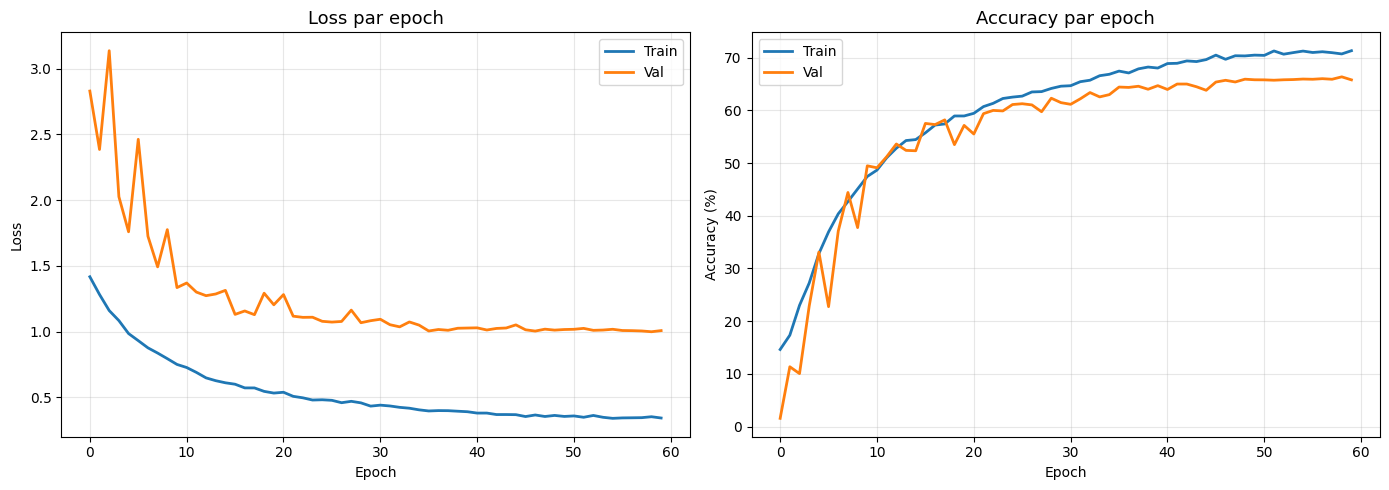

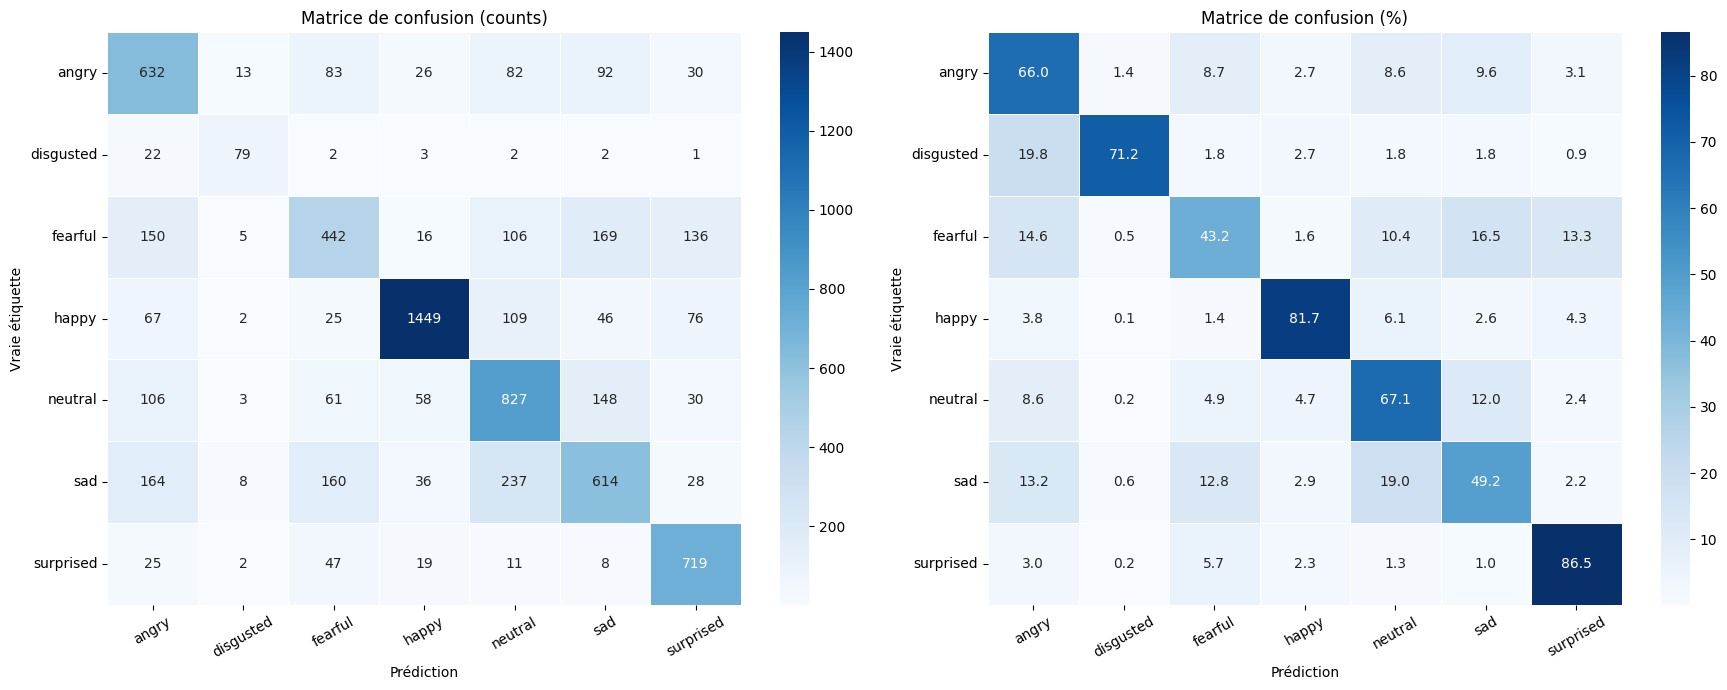


Accuracy globale : 66.34%

              precision    recall  f1-score   support

       angry       0.54      0.66      0.60       958
   disgusted       0.71      0.71      0.71       111
     fearful       0.54      0.43      0.48      1024
       happy       0.90      0.82      0.86      1774
     neutral       0.60      0.67      0.63      1233
         sad       0.57      0.49      0.53      1247
   surprised       0.70      0.87      0.78       831

    accuracy                           0.66      7178
   macro avg       0.65      0.66      0.65      7178
weighted avg       0.67      0.66      0.66      7178



In [8]:
def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    ax = axes[0]
    ax.plot(history["train_loss"], label="Train", linewidth=2)
    ax.plot(history["val_loss"], label="Val", linewidth=2)
    ax.set_title("Loss par epoch", fontsize=13)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(alpha=0.3)

    # Accuracy
    ax = axes[1]
    ax.plot([a * 100 for a in history["train_acc"]],
            label="Train", linewidth=2)
    ax.plot([a * 100 for a in history["val_acc"]],
            label="Val", linewidth=2)
    ax.set_title("Accuracy par epoch", fontsize=13)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy (%)")
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("training_history.png", dpi=150)
    plt.show()


def plot_confusion_matrix(model, loader):
    criterion = nn.CrossEntropyLoss()
    _, acc, preds, labels = evaluate(model, loader, criterion)
    cm = confusion_matrix(labels, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    for ax, data, fmt, title in zip(
        axes,
        [cm, cm_norm * 100],
        ["d", ".1f"],
        ["Matrice de confusion (counts)",
         "Matrice de confusion (%)"]
    ):
        sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues",
                    xticklabels=EMOTIONS, yticklabels=EMOTIONS,
                    ax=ax, linewidths=0.5)
        ax.set_title(title, fontsize=12)
        ax.set_ylabel("Vraie étiquette")
        ax.set_xlabel("Prédiction")
        ax.tick_params(axis='x', rotation=30)
        ax.tick_params(axis='y', rotation=0)

    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=150)
    plt.show()

    print(f"\nAccuracy globale : {acc * 100:.2f}%\n")
    print(classification_report(labels, preds,
                                 target_names=EMOTIONS))


plot_training_history(history)
plot_confusion_matrix(model, test_loader)

In [15]:
def export_onnx(model, path="emotion_model.onnx"):
    model.eval()
    dummy = torch.randn(1, 1, IMG_SIZE, IMG_SIZE).to(device)
    torch.onnx.export(
        model,
        dummy,
        path,
        export_params=True,
        opset_version=18,
        do_constant_folding=True,
        input_names=["input"],
        output_names=["output"],
        dynamic_axes={
            "input": {0: "batch_size"},
            "output": {0: "batch_size"},
        },
    )
    size_mb = os.path.getsize(path) / 1024 / 1024
    print(f"Modèle ONNX exporté : {path}  ({size_mb:.1f} MB)")


def verify_onnx(onnx_path="emotion_model.onnx"):
    import onnxruntime as ort
    session = ort.InferenceSession(
        onnx_path,
        providers=["CPUExecutionProvider"]
    )
    dummy = np.random.randn(1, 1, IMG_SIZE, IMG_SIZE).astype(np.float32)
    output = session.run(None, {"input": dummy})[0]
    print(f"ONNX output shape : {output.shape}  (attendu: [1, 7])")
    probs = np.exp(output) / np.exp(output).sum()
    print(f"Exemple de probas : {dict(zip(EMOTIONS, probs[0].round(3)))}")
    print("Vérification ONNX : OK")

!pip install onnxscript -q
export_onnx(model, "emotion_model.onnx")
verify_onnx("emotion_model.onnx")

# Sauvegarder aussi en .pth
torch.save({
    "model_state_dict": model.state_dict(),
    "emotions": EMOTIONS,
    "img_size": IMG_SIZE,
    "accuracy": max(history["val_acc"]),
}, "emotion_model_checkpoint.pth")
print("Checkpoint .pth sauvegardé.")

/tmp/ipykernel_1874/1535820551.py:4: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0418 17:01:37.676000 1874 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0418 17:01:37.678000 1874 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0418 17:01:37.680000 1874 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.

[torch.onnx] Obtain model graph for `EmotionCNN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `EmotionCNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 25 of general pattern rewrite rules.
Modèle ONNX exporté : emotion_model.onnx  (0.0 MB)
ONNX output shape : (1, 7)  (attendu: [1, 7])
Exemple de probas : {'angry': np.float32(0.313), 'disgusted': np.float32(0.0), 'fearful': np.float32(0.294), 'happy': np.float32(0.208), 'neutral': np.float32(0.009), 'sad': np.float32(0.023), 'surprised': np.float32(0.152)}
Vérification ONNX : OK
Checkpoint .pth sauvegardé.


In [16]:
from google.colab import files
files.download("emotion_model.onnx")
files.download("emotion_model_checkpoint.pth")
files.download("training_history.png")
files.download("confusion_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>